# Foundations of Scientific Computation

## Importing Scientific Libraries

In [14]:
import numpy as np
import quantecon as qe
import matplotlib.pyplot as plt
import random
from mpl_toolkits.mplot3d.axes3d import Axes3D
from matplotlib import cm

## Vectorization vs pure Python loops

- Not all algorithms can be vectorized
- Vectorization tends to be memory intensive since it generates many intermediate arrays before producing the final calculation
- At best, vectorization yields fast, simple code

In [10]:
#Constants 

n = 1_000_000

In [11]:
# Non-vectorized code
with qe.Timer():
    y = 0
    for i in range(n):
        x = random.uniform(0, 1)
        y += x**2
    print(f'Total(Y) = {y}')

Total(Y) = 333410.1260476998
0.2507 seconds elapsed


In [12]:
# Vectorized code
rng = np.random.default_rng()

with qe.Timer():
    x = rng.uniform(0, 1, n)
    y = np.sum(x**2)
    print(f'Total(Y) = {y}')

Total(Y) = 333645.81637305924
0.0123 seconds elapsed


## Numpy Review

In [15]:
import numpy as np
import quantecon as qe
import matplotlib.pyplot as plt
import random
from mpl_toolkits.mplot3d.axes3d import Axes3D
from matplotlib import cm

In [17]:
a = np.zeros(3)
a, type(a)

(array([0., 0., 0.]), numpy.ndarray)

In [20]:
b = np.zeros(3, dtype=int)
b, type(b)

(array([0, 0, 0]), numpy.ndarray)

In [22]:
z = np.zeros(10)
z.shape = (2, 5)
z

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [23]:
z = np.linspace(2, 4, 5)
z

array([2. , 2.5, 3. , 3.5, 4. ])

In [28]:
z = np.identity(2)
z

array([[1., 0.],
       [0., 1.]])

In [33]:
# creating np arrays from python lists

z = np.array([10, 20], dtype=float)
z, type(z), z[0], z[-1]

(array([10., 20.]), numpy.ndarray, np.float64(10.0), np.float64(20.0))

In [36]:
# Creating a 2D array
z = np.array([[1,2], [3, 4]])
z, type(z), z[0, 0]

(array([[1, 2],
        [3, 4]]),
 numpy.ndarray,
 np.int64(1))

In [44]:
# boolean array

d = np.array([0, 1, 1, 0, 0], dtype=bool)
d

array([False,  True,  True, False, False])

In [45]:
z = np.empty(3)
z[:] = 42
z

array([42., 42., 42.])

In [50]:
# Array Methods

a = np.array([4, 3, 2, 1])

a.sort(), #sorts array
a.sum(),  #sums elements of array
a.mean(), #finds mean of array elements
a.max(),  #finds array max
a.argmax(), #finds index of max element
a.cumsum(), #cumulative sum of the elements of a
a.cumprod(), #cumulaive product of array elements
a.var(), #finds variance of array
a.std(), #finds std of array
a.T #transposes array


array([1, 2, 3, 4])

In [49]:
# Arithmetic operators

a = np.array([1, 2, 3, 4])
b = np.array([5, 6, 7, 8])

a + b, a * b, a + 10, a * 10

(array([ 6,  8, 10, 12]),
 array([ 5, 12, 21, 32]),
 array([11, 12, 13, 14]),
 array([10, 20, 30, 40]))

In [53]:
# Matrices
A = np.ones((2, 2))
B = np.ones((2, 2))

A + B, A + 10, A * B, A @ A

(array([[2., 2.],
        [2., 2.]]),
 array([[11., 11.],
        [11., 11.]]),
 array([[1., 1.],
        [1., 1.]]),
 array([[2., 2.],
        [2., 2.]]))

In [59]:
# Broadcasting

a = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

b = np.array([3, 6, 9])

# b which is initially b -> (3, ) is broadcasted to (3, 3)

a + b

array([[ 4,  8, 12],
       [ 7, 11, 15],
       [10, 14, 18]])

In [62]:
# Broadcasting

a = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

b = np.array([3, 6, 9])

# b which is initially b -> (3, ) is broadcasted to (3, 3)

b.shape = (3, 1)
b, a + b

(array([[3],
        [6],
        [9]]),
 array([[ 4,  5,  6],
        [10, 11, 12],
        [16, 17, 18]]))

In [64]:
# Broadcasting, expanding both

a = np.array([3, 6, 9])
b = np.array([2, 3, 4])

b.shape = (3, 1)

a, b, a + b

(array([3, 6, 9]),
 array([[2],
        [3],
        [4]]),
 array([[ 5,  8, 11],
        [ 6,  9, 12],
        [ 7, 10, 13]]))

In [65]:
# Vectorizing

def f(x):
    return 1 if x > 0 else 0

x = np.random.randn(4)
f = np.vectorize(f)
f(x)

array([1, 1, 0, 1])

## Scipy

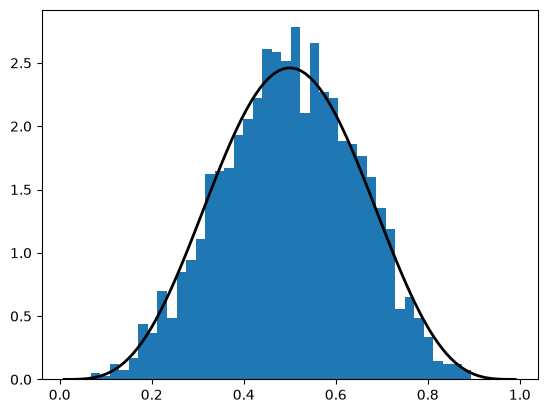

In [75]:
import numpy as np
import quantecon as qe
import matplotlib.pyplot as plt
import random
from mpl_toolkits.mplot3d.axes3d import Axes3D
from matplotlib import cm
from scipy.stats import beta


q = beta(5, 5) # a = 5, b = 5
obs = q.rvs(2000) #2000 observations


grid = np.linspace(0.01, 0.99, 100)

fig, ax = plt.subplots()
ax.hist(obs, bins=40, density=True)
ax.plot(grid, q.pdf(grid), 'k-', linewidth=2)

plt.show()

NameError: name 'pl' is not defined

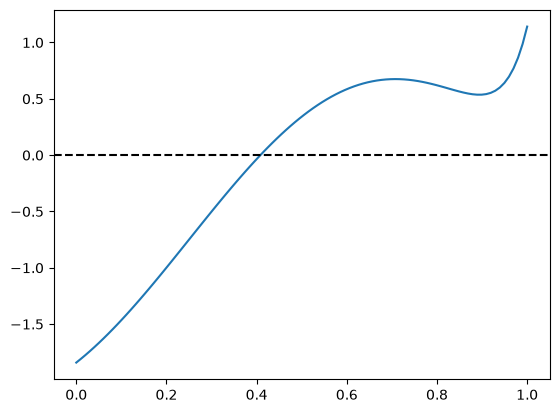

In [76]:
f = lambda x : np.sin(4 * (x - 1/4)) + x + x ** 20 - 1
x = np.linspace(0, 1, 100)


fig, ax = plt.subplots()
ax.plot(x, f(x), label='$f(x)$')
ax.axhline(ls='--', c='k')

pl.show()